# CUSTOMER DATASET - EXPLORATORY & BUSINESS ANALYSIS

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

# 1. LOAD CLEAN DATASET

In [ ]:
uploaded = files.upload()

# Get uploaded file name
file_name = next(iter(uploaded))

print(f"Uploaded file: {file_name}")

# Read Excel
df = pd.read_excel(file_name)

print("\nDataset loaded successfully.")

print("=" * 70)
print("CUSTOMER DATASET - BUSINESS ANALYSIS")
print("=" * 70)

print(f"Number of Customers: {len(df):,}")
print(f"Number of Features: {df.shape[1]}")

Saving cleaned_customer_dataset.xlsx to cleaned_customer_dataset (1).xlsx
Uploaded file: cleaned_customer_dataset (1).xlsx

Dataset loaded successfully.
CUSTOMER DATASET - BUSINESS ANALYSIS
Number of Customers: 60
Number of Features: 21


# 2. GENDER ANALYSIS


1. GENDER DISTRIBUTION
  Gender  Customers  Percentage
0      M         36        60.0
1      F         24        40.0


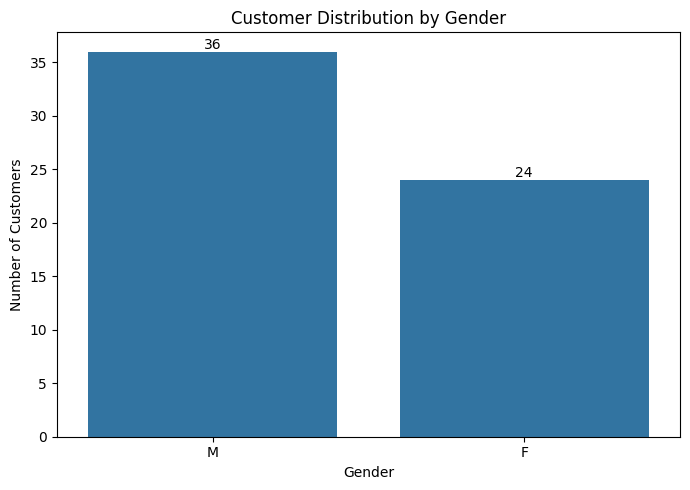

In [ ]:
gender_summary = (
    df["gender"]
    .value_counts()
    .rename_axis("Gender")
    .reset_index(name="Customers")
)

gender_summary["Percentage"] = (
    gender_summary["Customers"] / len(df) * 100
)

print("\n" + "=" * 70)
print("1. GENDER DISTRIBUTION")
print("=" * 70)
print(gender_summary)

plt.figure(figsize=(7, 5))
ax = sns.barplot(
    data=gender_summary,
    x="Gender",
    y="Customers"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%d")

plt.title("Customer Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

# 3. CITY ANALYSIS


2. CUSTOMER DISTRIBUTION BY CITY
         Customers  Total_Revenue  Avg_Spending  Avg_Satisfaction  \
city                                                                
Tabriz          12       36192.49       3016.04              3.00   
Mashhad         11       64118.44       5828.95              2.91   
Ahvaz            8       23384.78       2923.10              3.50   
Karaj            7       26189.81       3741.40              2.86   
Tehran           6       15161.29       2526.88              2.67   
Shiraz           6       20715.92       3452.65              2.00   
Isfahan          5       21975.32       4395.06              4.40   
Rasht            5       15168.54       3033.71              2.60   

         Customer_Percentage  
city                          
Tabriz                 20.00  
Mashhad                18.33  
Ahvaz                  13.33  
Karaj                  11.67  
Tehran                 10.00  
Shiraz                 10.00  
Isfahan                 8.3

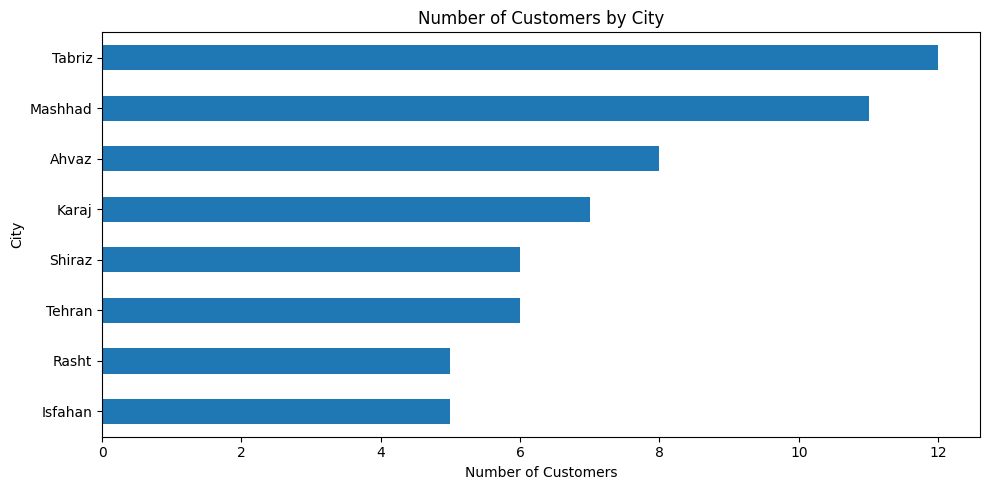

In [ ]:
city_summary = (
    df.groupby("city")
    .agg(
        Customers=("customer_id", "count"),
        Total_Revenue=("total_spending", "sum"),
        Avg_Spending=("total_spending", "mean"),
        Avg_Satisfaction=("satisfaction_score", "mean")
    )
    .sort_values("Customers", ascending=False)
)

city_summary["Customer_Percentage"] = (
    city_summary["Customers"] / len(df) * 100
)

print("\n" + "=" * 70)
print("2. CUSTOMER DISTRIBUTION BY CITY")
print("=" * 70)
print(city_summary.round(2))

plt.figure(figsize=(10, 5))
city_summary["Customers"].sort_values(ascending=True).plot(kind="barh")

plt.title("Number of Customers by City")
plt.xlabel("Number of Customers")
plt.ylabel("City")
plt.tight_layout()
plt.show()

# 4. PROVINCE ANALYSIS


3. CUSTOMER DISTRIBUTION BY PROVINCE
                 Customers  Total_Revenue  Avg_Spending  Percentage
province                                                           
East Azerbaijan         12       36192.49       3016.04       20.00
Khorasan                11       64118.44       5828.95       18.33
Khuzestan                8       23384.78       2923.10       13.33
Alborz                   7       26189.81       3741.40       11.67
Tehran                   6       15161.29       2526.88       10.00
Fars                     6       20715.92       3452.65       10.00
Gilan                    5       15168.54       3033.71        8.33
Isfahan                  5       21975.32       4395.06        8.33


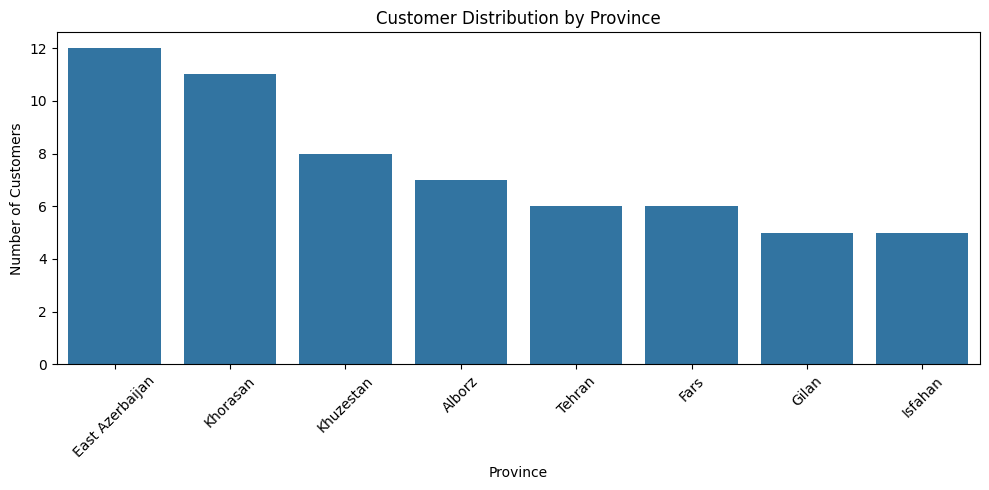

In [ ]:
province_summary = (
    df.groupby("province")
    .agg(
        Customers=("customer_id", "count"),
        Total_Revenue=("total_spending", "sum"),
        Avg_Spending=("total_spending", "mean")
    )
    .sort_values("Customers", ascending=False)
)

province_summary["Percentage"] = (
    province_summary["Customers"] / len(df) * 100
)

print("\n" + "=" * 70)
print("3. CUSTOMER DISTRIBUTION BY PROVINCE")
print("=" * 70)
print(province_summary.round(2))

plt.figure(figsize=(10, 5))
sns.barplot(
    x=province_summary.index,
    y=province_summary["Customers"]
)

plt.title("Customer Distribution by Province")
plt.xlabel("Province")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 5. MEMBERSHIP TIER ANALYSIS


4. MEMBERSHIP TIER ANALYSIS
                 Customers  Avg_Spending  Total_Revenue  Avg_Purchases  \
membership_tier                                                          
Gold                    19       3955.43       75153.20          17.05   
Bronze                  18       3166.66       56999.81          16.89   
VIP                     15       3820.94       57314.17          18.87   
Silver                   8       4179.93       33439.41          16.50   

                 Avg_Satisfaction  Percentage  
membership_tier                                
Gold                         2.74       31.67  
Bronze                       3.11       30.00  
VIP                          3.40       25.00  
Silver                       2.50       13.33  


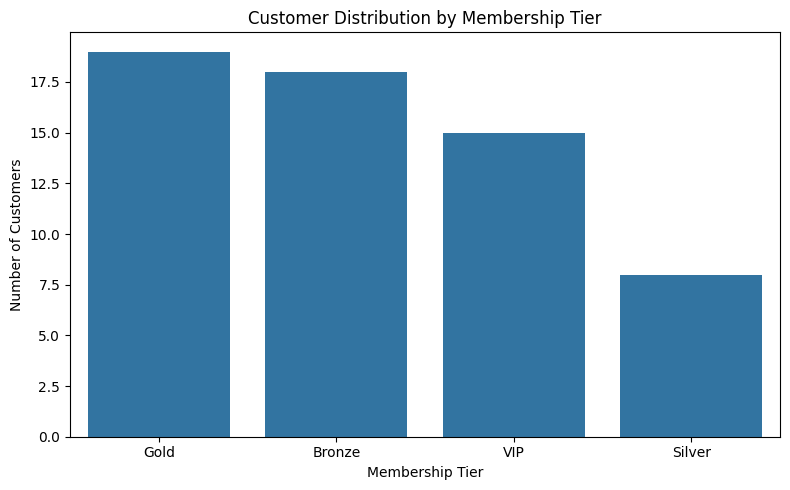

In [ ]:
membership_summary = (
    df.groupby("membership_tier")
    .agg(
        Customers=("customer_id", "count"),
        Avg_Spending=("total_spending", "mean"),
        Total_Revenue=("total_spending", "sum"),
        Avg_Purchases=("purchase_count", "mean"),
        Avg_Satisfaction=("satisfaction_score", "mean")
    )
    .sort_values("Customers", ascending=False)
)

membership_summary["Percentage"] = (
    membership_summary["Customers"] / len(df) * 100
)

print("\n" + "=" * 70)
print("4. MEMBERSHIP TIER ANALYSIS")
print("=" * 70)
print(membership_summary.round(2))

plt.figure(figsize=(8, 5))
sns.barplot(
    x=membership_summary.index,
    y=membership_summary["Customers"]
)

plt.title("Customer Distribution by Membership Tier")
plt.xlabel("Membership Tier")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()



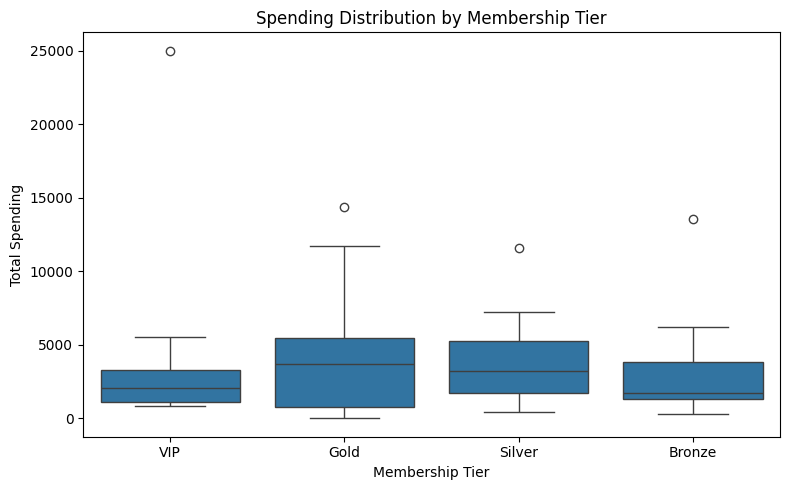

In [ ]:
# Membership vs Spending
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="membership_tier",
    y="total_spending"
)

plt.title("Spending Distribution by Membership Tier")
plt.xlabel("Membership Tier")
plt.ylabel("Total Spending")
plt.tight_layout()
plt.show()

# 6. PURCHASE COUNT ANALYSIS


5. PURCHASE BEHAVIOR
Minimum Purchases: 0
Maximum Purchases: 35
Average Purchases: 17.38
Median Purchases: 17.00

Customers with the highest number of purchases:
   customer_id first_name  purchase_count  total_spending membership_tier
5         1006       Amir              35         3868.55            Gold

Customers with the lowest number of purchases:
    customer_id first_name  purchase_count  total_spending membership_tier
23         1024       Sina               0             0.0            Gold


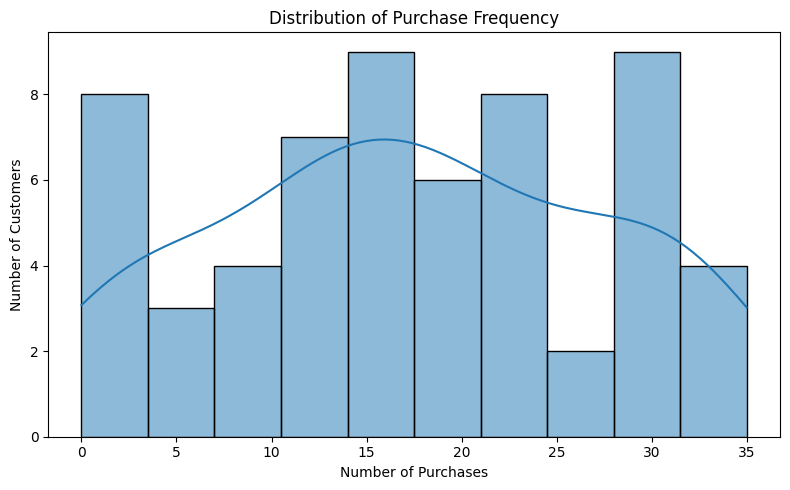

In [ ]:
print("\n" + "=" * 70)
print("5. PURCHASE BEHAVIOR")
print("=" * 70)

print(f"Minimum Purchases: {df['purchase_count'].min()}")
print(f"Maximum Purchases: {df['purchase_count'].max()}")
print(f"Average Purchases: {df['purchase_count'].mean():.2f}")
print(f"Median Purchases: {df['purchase_count'].median():.2f}")

max_purchase = df["purchase_count"].max()
min_purchase = df["purchase_count"].min()

most_active = df[df["purchase_count"] == max_purchase]

least_active = df[df["purchase_count"] == min_purchase]

print("\nCustomers with the highest number of purchases:")
print(
    most_active[
        ["customer_id", "first_name", "purchase_count",
         "total_spending", "membership_tier"]
    ]
)

print("\nCustomers with the lowest number of purchases:")
print(
    least_active[
        ["customer_id", "first_name", "purchase_count",
         "total_spending", "membership_tier"]
    ]
)


# Purchase distribution
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="purchase_count",
    bins=10,
    kde=True
)

plt.title("Distribution of Purchase Frequency")
plt.xlabel("Number of Purchases")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()


# 7. DEVICE ANALYSIS


6. DEVICE USAGE
    Device  Customers  Percentage
0  Android         22   36.666667
1      Web         20   33.333333
2   iPhone         18   30.000000


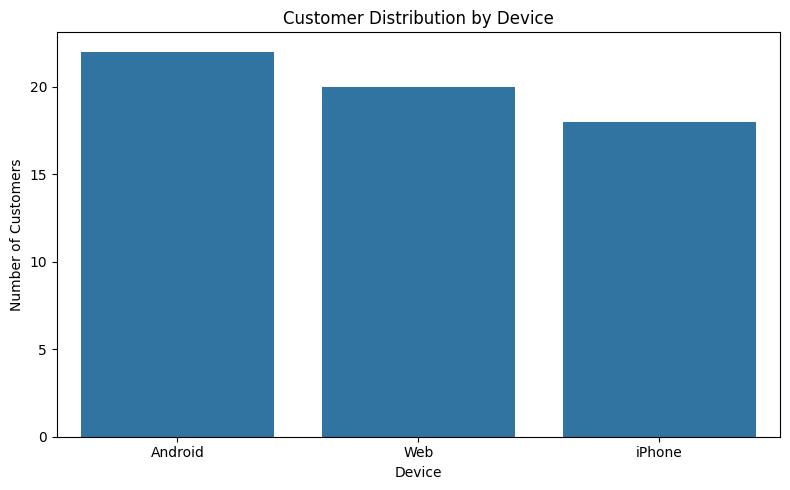

In [ ]:
device_summary = (
    df["device"]
    .value_counts()
    .rename_axis("Device")
    .reset_index(name="Customers")
)

device_summary["Percentage"] = (
    device_summary["Customers"] / len(df) * 100
)

print("\n" + "=" * 70)
print("6. DEVICE USAGE")
print("=" * 70)
print(device_summary)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=device_summary,
    x="Device",
    y="Customers"
)

plt.title("Customer Distribution by Device")
plt.xlabel("Device")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

# 8. PAYMENT METHOD ANALYSIS


7. PAYMENT METHOD ANALYSIS
  Payment_Method  Customers  Percentage
0  Online Wallet         23   38.333333
1           Cash         19   31.666667
2           Card         18   30.000000


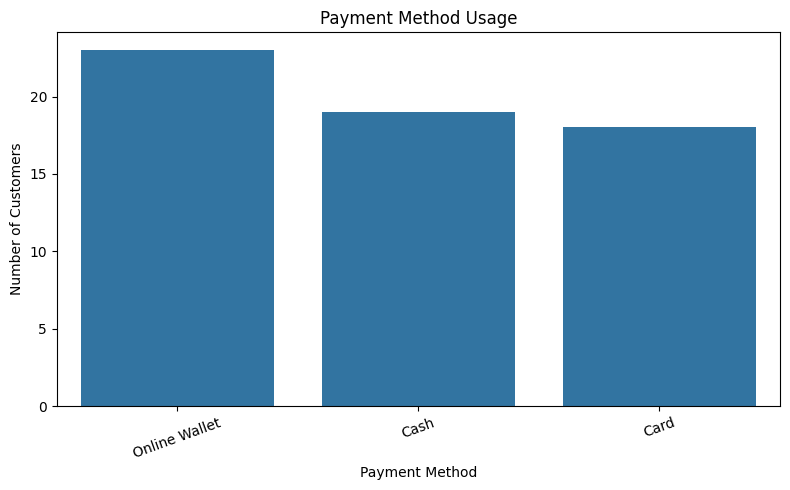

In [ ]:
payment_summary = (
    df["payment_method"]
    .value_counts()
    .rename_axis("Payment_Method")
    .reset_index(name="Customers")
)

payment_summary["Percentage"] = (
    payment_summary["Customers"] / len(df) * 100
)

print("\n" + "=" * 70)
print("7. PAYMENT METHOD ANALYSIS")
print("=" * 70)
print(payment_summary)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=payment_summary,
    x="Payment_Method",
    y="Customers"
)

plt.title("Payment Method Usage")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


In [ ]:
# Payment method vs spending
payment_business = (
    df.groupby("payment_method")
    .agg(
        Customers=("customer_id", "count"),
        Avg_Order_Value=("avg_order_value", "mean"),
        Avg_Spending=("total_spending", "mean"),
        Total_Revenue=("total_spending", "sum"),
        Avg_Satisfaction=("satisfaction_score", "mean")
    )
    .sort_values("Avg_Spending", ascending=False)
)

print("\nPayment Method Business Performance:")
print(payment_business.round(2))


Payment Method Business Performance:
                Customers  Avg_Order_Value  Avg_Spending  Total_Revenue  \
payment_method                                                            
Cash                   19           192.26       4251.68       80781.87   
Card                   18           224.14       3929.00       70722.09   
Online Wallet          23           221.82       3104.46       71402.63   

                Avg_Satisfaction  
payment_method                    
Cash                        3.47  
Card                        3.28  
Online Wallet               2.35  


# 9. DISCOUNT ANALYSIS

In [ ]:
discount_summary = (
    df.groupby("discount_used")
    .agg(
        Customers=("customer_id", "count"),
        Avg_Spending=("total_spending", "mean"),
        Avg_Purchases=("purchase_count", "mean"),
        Avg_Order_Value=("avg_order_value", "mean"),
        Avg_Satisfaction=("satisfaction_score", "mean")
    )
)

discount_summary["Percentage"] = (
    discount_summary["Customers"] / len(df) * 100
)

print("\n" + "=" * 70)
print("8. DISCOUNT USAGE ANALYSIS")
print("=" * 70)
print(discount_summary.round(2))


8. DISCOUNT USAGE ANALYSIS
               Customers  Avg_Spending  Avg_Purchases  Avg_Order_Value  \
discount_used                                                            
No                    34       3736.74          17.29           220.70   
Yes                   26       3686.82          17.50           203.29   

               Avg_Satisfaction  Percentage  
discount_used                                
No                         2.76       56.67  
Yes                        3.27       43.33  


# 10. CUSTOMER ACTIVITY ANALYSIS


9. CUSTOMER ACTIVITY ANALYSIS
                Customers  Avg_Spending  Avg_Purchases  Avg_Return_Rate  \
activity_level                                                            
Active                  6       4187.80          16.67             0.69   
At Risk                15       3352.00          20.20             0.28   
Highly Active           4       2556.76          16.50             0.24   
Inactive               35       3922.08          16.40             0.72   

                Avg_Satisfaction  Percentage  
activity_level                                
Active                      4.00       10.00  
At Risk                     3.27       25.00  
Highly Active               3.50        6.67  
Inactive                    2.63       58.33  


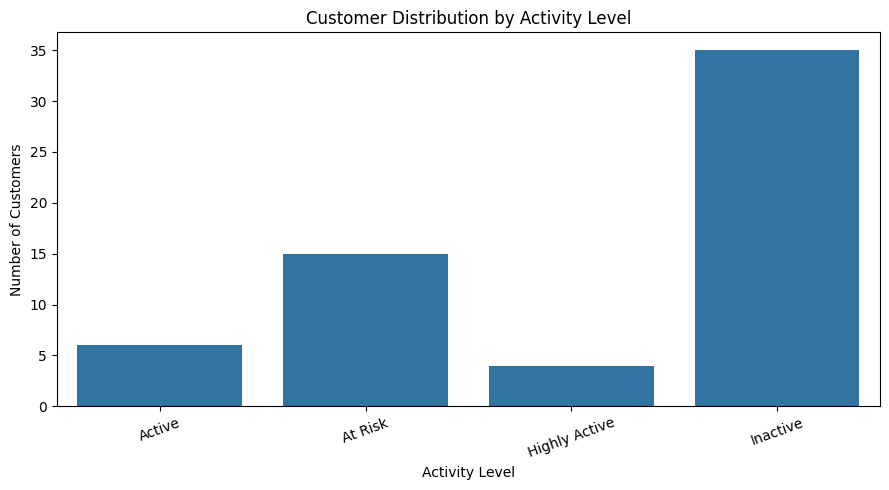

In [ ]:
activity_summary = (
    df.groupby("activity_level", observed=True)
    .agg(
        Customers=("customer_id", "count"),
        Avg_Spending=("total_spending", "mean"),
        Avg_Purchases=("purchase_count", "mean"),
        Avg_Return_Rate=("return_rate", "mean"),
        Avg_Satisfaction=("satisfaction_score", "mean")
    )
)

activity_summary["Percentage"] = (
    activity_summary["Customers"] / len(df) * 100
)

print("\n" + "=" * 70)
print("9. CUSTOMER ACTIVITY ANALYSIS")
print("=" * 70)
print(activity_summary.round(2))


plt.figure(figsize=(9, 5))

sns.barplot(
    data=activity_summary.reset_index(),
    x="activity_level",
    y="Customers"
)

plt.title("Customer Distribution by Activity Level")
plt.xlabel("Activity Level")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


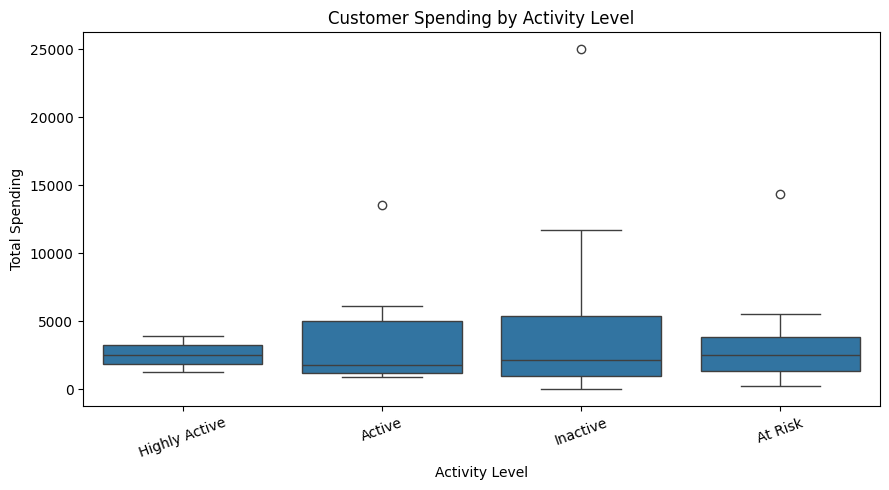

In [ ]:
# Activity vs spending
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="activity_level",
    y="total_spending"
)

plt.title("Customer Spending by Activity Level")
plt.xlabel("Activity Level")
plt.ylabel("Total Spending")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


# 11. CUSTOMER VALUE ANALYSIS


10. CUSTOMER VALUE ANALYSIS
                Customers  Avg_Spending  Total_Revenue  Avg_Purchases  \
customer_value                                                          
High Value             20       7909.13      158182.68          23.95   
Low Value              20        836.98       16739.57          10.50   
Medium Value           20       2399.22       47984.34          17.70   

                Avg_Order_Value  Avg_Satisfaction  Avg_Return_Rate  Percentage  
customer_value                                                                  
High Value               289.51              2.90             0.20       33.33  
Low Value                183.08              2.95             1.22       33.33  
Medium Value             166.88              3.10             0.33       33.33  


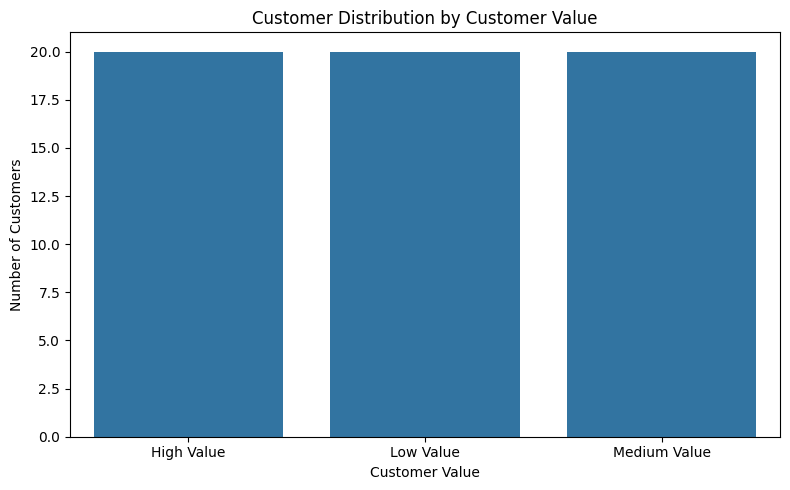

In [ ]:
value_summary = (
    df.groupby("customer_value", observed=True)
    .agg(
        Customers=("customer_id", "count"),
        Avg_Spending=("total_spending", "mean"),
        Total_Revenue=("total_spending", "sum"),
        Avg_Purchases=("purchase_count", "mean"),
        Avg_Order_Value=("avg_order_value", "mean"),
        Avg_Satisfaction=("satisfaction_score", "mean"),
        Avg_Return_Rate=("return_rate", "mean")
    )
)

value_summary["Percentage"] = (
    value_summary["Customers"] / len(df) * 100
)

print("\n" + "=" * 70)
print("10. CUSTOMER VALUE ANALYSIS")
print("=" * 70)
print(value_summary.round(2))


# Customer value distribution
plt.figure(figsize=(8, 5))

sns.barplot(
    data=value_summary.reset_index(),
    x="customer_value",
    y="Customers"
)

plt.title("Customer Distribution by Customer Value")
plt.xlabel("Customer Value")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

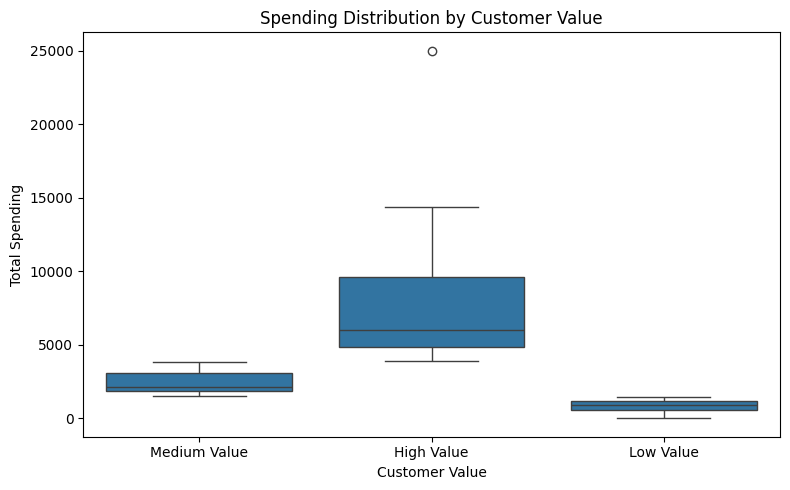

In [ ]:
# Customer value vs spending
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="customer_value",
    y="total_spending"
)

plt.title("Spending Distribution by Customer Value")
plt.xlabel("Customer Value")
plt.ylabel("Total Spending")
plt.tight_layout()
plt.show()


# 12. RETURN RATE ANALYSIS


11. RETURN BEHAVIOR
                Customers  Avg_Return_Rate  Avg_Returned_Items  \
customer_value                                                   
High Value             20            0.202                4.40   
Low Value              20            1.222                3.60   
Medium Value           20            0.331                4.55   

                Avg_Satisfaction  
customer_value                    
High Value                  2.90  
Low Value                   2.95  
Medium Value                3.10  


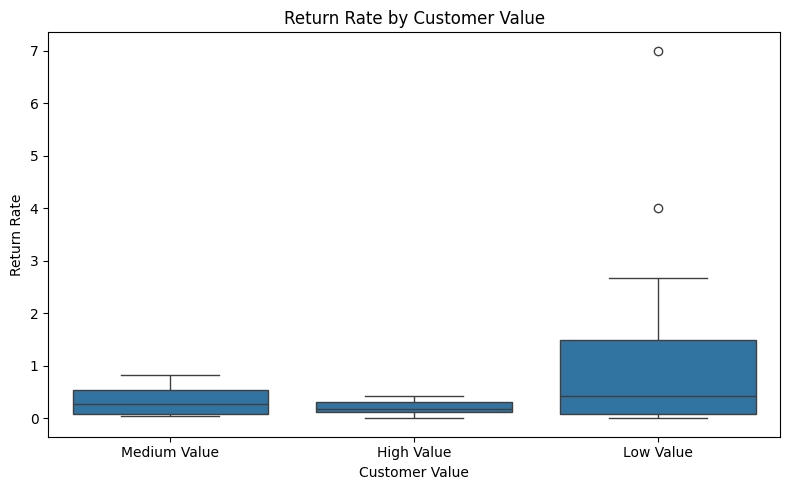

In [ ]:
return_summary = (
    df.groupby("customer_value", observed=True)
    .agg(
        Customers=("customer_id", "count"),
        Avg_Return_Rate=("return_rate", "mean"),
        Avg_Returned_Items=("returned_items", "mean"),
        Avg_Satisfaction=("satisfaction_score", "mean")
    )
)

print("\n" + "=" * 70)
print("11. RETURN BEHAVIOR")
print("=" * 70)
print(return_summary.round(3))


plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="customer_value",
    y="return_rate"
)

plt.title("Return Rate by Customer Value")
plt.xlabel("Customer Value")
plt.ylabel("Return Rate")
plt.tight_layout()
plt.show()

# 13. SATISFACTION ANALYSIS


12. CUSTOMER SATISFACTION
                    Customers  Avg_Spending  Avg_Purchases  Avg_Return_Rate
satisfaction_score                                                         
1                          11       3124.81          15.45             0.58
2                          16       3866.36          16.44             0.97
3                           8       2963.69          17.00             0.37
4                          13       5448.63          22.23             0.35
5                          12       2677.52          15.42             0.42


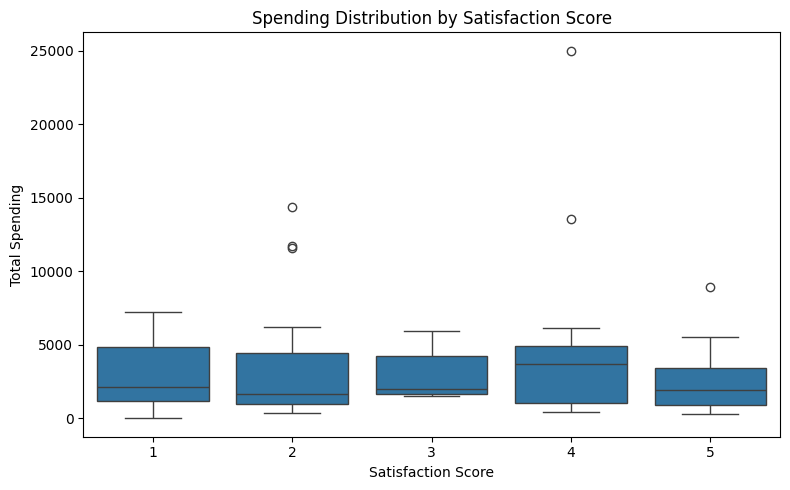

In [ ]:
satisfaction_summary = (
    df.groupby("satisfaction_score")
    .agg(
        Customers=("customer_id", "count"),
        Avg_Spending=("total_spending", "mean"),
        Avg_Purchases=("purchase_count", "mean"),
        Avg_Return_Rate=("return_rate", "mean")
    )
    .sort_index()
)

print("\n" + "=" * 70)
print("12. CUSTOMER SATISFACTION")
print("=" * 70)
print(satisfaction_summary.round(2))


plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="satisfaction_score",
    y="total_spending"
)

plt.title("Spending Distribution by Satisfaction Score")
plt.xlabel("Satisfaction Score")
plt.ylabel("Total Spending")
plt.tight_layout()
plt.show()

# 14. AGE ANALYSIS


13. AGE ANALYSIS
Average Age: 43.70
Median Age: 45.00
Youngest Customer: 19
Oldest Customer: 65


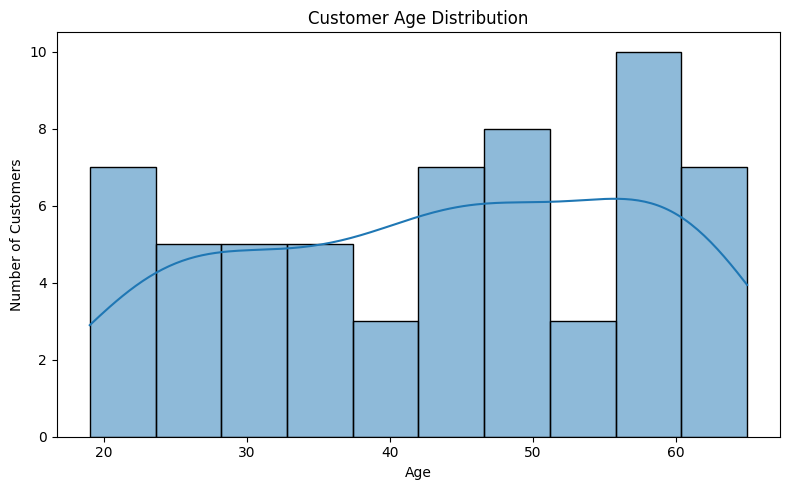

In [ ]:
print("\n" + "=" * 70)
print("13. AGE ANALYSIS")
print("=" * 70)

print(f"Average Age: {df['age'].mean():.2f}")
print(f"Median Age: {df['age'].median():.2f}")
print(f"Youngest Customer: {df['age'].min()}")
print(f"Oldest Customer: {df['age'].max()}")

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="age",
    bins=10,
    kde=True
)

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

# 15. AVG ORDER VALUE ANALYSIS


14. AVERAGE ORDER VALUE
                 Customers  Avg_Order_Value  Avg_Total_Spending
membership_tier                                                
Silver                   8           281.53             4179.93
Gold                    19           230.91             3955.43
Bronze                  18           203.45             3166.66
VIP                     15           165.85             3820.94


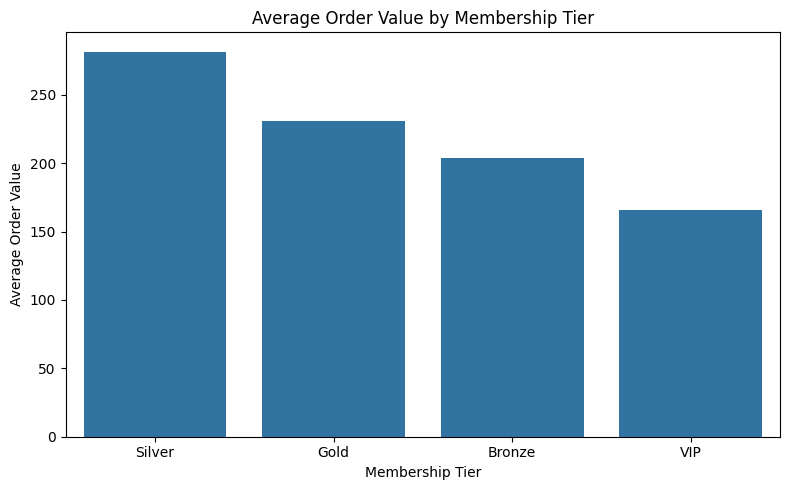

In [ ]:
aov_summary = (
    df.groupby("membership_tier")
    .agg(
        Customers=("customer_id", "count"),
        Avg_Order_Value=("avg_order_value", "mean"),
        Avg_Total_Spending=("total_spending", "mean")
    )
    .sort_values("Avg_Order_Value", ascending=False)
)

print("\n" + "=" * 70)
print("14. AVERAGE ORDER VALUE")
print("=" * 70)
print(aov_summary.round(2))


plt.figure(figsize=(8, 5))

sns.barplot(
    data=aov_summary.reset_index(),
    x="membership_tier",
    y="Avg_Order_Value"
)

plt.title("Average Order Value by Membership Tier")
plt.xlabel("Membership Tier")
plt.ylabel("Average Order Value")
plt.tight_layout()
plt.show()

# 16. PURCHASE COUNT vs TOTAL SPENDING

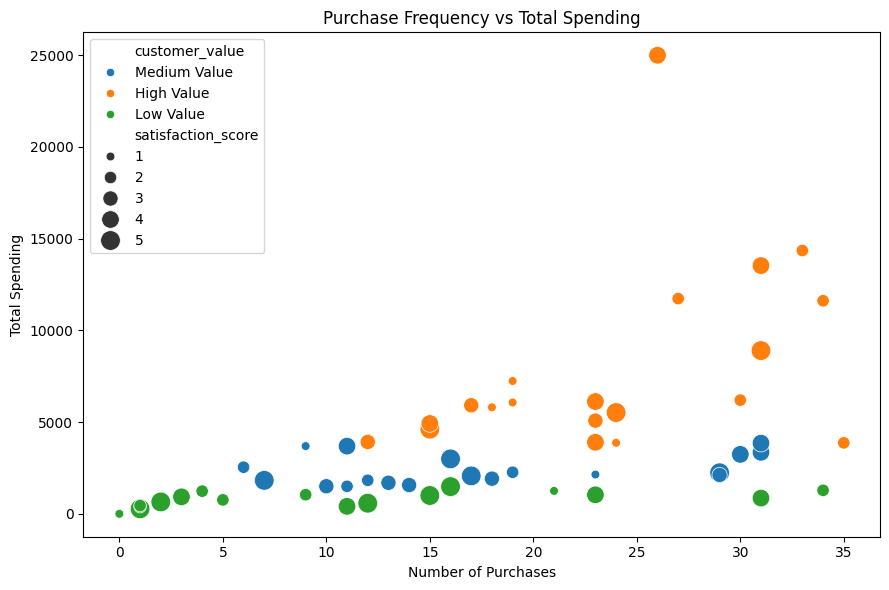

In [ ]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="purchase_count",
    y="total_spending",
    hue="customer_value",
    size="satisfaction_score",
    sizes=(40, 200)
)

plt.title("Purchase Frequency vs Total Spending")
plt.xlabel("Number of Purchases")
plt.ylabel("Total Spending")
plt.tight_layout()
plt.show()

# 17. CORRELATION ANALYSIS


15. CORRELATION ANALYSIS
                     age  purchase_count  avg_order_value  total_spending  \
age                 1.00            0.25             0.19            0.36   
purchase_count      0.25            1.00            -0.26            0.51   
avg_order_value     0.19           -0.26             1.00            0.35   
total_spending      0.36            0.51             0.35            1.00   
last_purchase_days -0.07           -0.12             0.06            0.09   
returned_items     -0.02            0.01             0.16            0.06   
satisfaction_score -0.11            0.09            -0.16            0.02   
return_rate        -0.02           -0.54             0.41           -0.25   

                    last_purchase_days  returned_items  satisfaction_score  \
age                              -0.07           -0.02               -0.11   
purchase_count                   -0.12            0.01                0.09   
avg_order_value                   0.06        

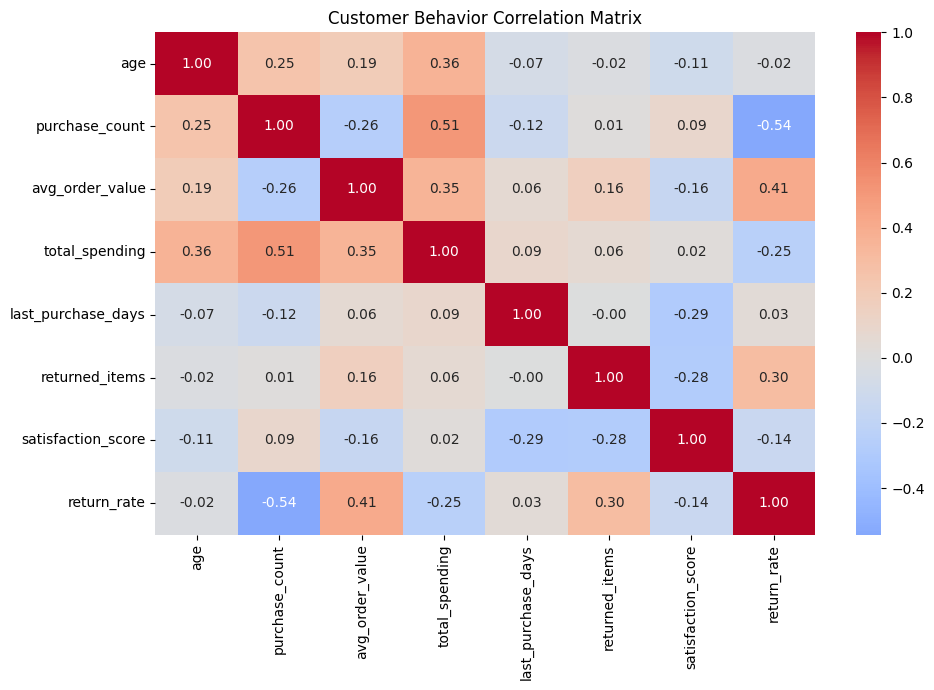

In [ ]:
numeric_columns = [
    "age",
    "purchase_count",
    "avg_order_value",
    "total_spending",
    "last_purchase_days",
    "returned_items",
    "satisfaction_score",
    "return_rate"
]

corr = df[numeric_columns].corr()

print("\n" + "=" * 70)
print("15. CORRELATION ANALYSIS")
print("=" * 70)

print(corr.round(2))

plt.figure(figsize=(10, 7))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Customer Behavior Correlation Matrix")
plt.tight_layout()
plt.show()

# 18. AUTOMATIC BUSINESS INSIGHTS

In [ ]:
print("\n" + "=" * 70)
print("KEY BUSINESS INSIGHTS")
print("=" * 70)

# Largest customer segment
largest_gender = df["gender"].value_counts().idxmax()
largest_city = df["city"].value_counts().idxmax()
largest_membership = df["membership_tier"].value_counts().idxmax()
largest_device = df["device"].value_counts().idxmax()
largest_payment = df["payment_method"].value_counts().idxmax()
largest_value = df["customer_value"].value_counts().idxmax()
largest_activity = df["activity_level"].value_counts().idxmax()

print(f"• Most common gender: {largest_gender}")
print(f"• City with most customers: {largest_city}")
print(f"• Most common membership tier: {largest_membership}")
print(f"• Most commonly used device: {largest_device}")
print(f"• Most common payment method: {largest_payment}")
print(f"• Largest customer value segment: {largest_value}")
print(f"• Largest activity segment: {largest_activity}")

# Highest revenue city
highest_revenue_city = city_summary["Total_Revenue"].idxmax()

print(
    f"• City generating the highest total revenue: "
    f"{highest_revenue_city}"
)

# Highest spending membership
highest_spending_membership = (
    membership_summary["Avg_Spending"].idxmax()
)

print(
    f"• Membership tier with highest average spending: "
    f"{highest_spending_membership}"
)

# Highest spending payment method
highest_spending_payment = (
    payment_business["Avg_Spending"].idxmax()
)

print(
    f"• Payment method associated with highest average spending: "
    f"{highest_spending_payment}"
)

# Highest value segment revenue
highest_value_revenue = (
    value_summary["Total_Revenue"].idxmax()
)

print(
    f"• Customer value segment generating highest revenue: "
    f"{highest_value_revenue}"
)

# Overall metrics
print(f"• Average customer spending: {df['total_spending'].mean():,.2f}")
print(f"• Average purchase count: {df['purchase_count'].mean():.2f}")
print(f"• Average satisfaction score: {df['satisfaction_score'].mean():.2f}")
print(f"• Average return rate: {df['return_rate'].mean():.2%}")

print("\nAnalysis completed successfully!")


KEY BUSINESS INSIGHTS
• Most common gender: M
• City with most customers: Tabriz
• Most common membership tier: Gold
• Most commonly used device: Android
• Most common payment method: Online Wallet
• Largest customer value segment: Medium Value
• Largest activity segment: Inactive
• City generating the highest total revenue: Mashhad
• Membership tier with highest average spending: Silver
• Payment method associated with highest average spending: Cash
• Customer value segment generating highest revenue: High Value
• Average customer spending: 3,715.11
• Average purchase count: 17.38
• Average satisfaction score: 2.98
• Average return rate: 57.43%

Analysis completed successfully!
